Importing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('DSNY_Monthly_Tonnage_Data_20251117.csv')

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24647 entries, 0 to 24646
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MONTH                24647 non-null  object 
 1   BOROUGH              24647 non-null  object 
 2   COMMUNITYDISTRICT    24647 non-null  int64  
 3   REFUSETONSCOLLECTED  24647 non-null  float64
 4   PAPERTONSCOLLECTED   22213 non-null  float64
 5   MGPTONSCOLLECTED     22570 non-null  float64
 6   RESORGANICSTONS      3095 non-null   float64
 7   SCHOOLORGANICTONS    2308 non-null   float64
 8   LEAVESORGANICTONS    881 non-null    object 
 9   XMASTREETONS         1685 non-null   float64
 10  OTHERORGANICSTONS    1933 non-null   float64
 11  BOROUGH_ID           24647 non-null  int64  
dtypes: float64(7), int64(2), object(3)
memory usage: 2.3+ MB


,MONTH,BOROUGH,COMMUNITYDISTRICT,REFUSETONSCOLLECTED,PAPERTONSCOLLECTED,MGPTONSCOLLECTED,RESORGANICSTONS,SCHOOLORGANICTONS,LEAVESORGANICTONS,XMASTREETONS,OTHERORGANICSTONS,BOROUGH_ID
0,2025 / 10,Bronx,1,3352.0,235.0,124.8,16.7,85.9,NaN,NaN,NaN,2
1,2025 / 10,Bronx,2,7942.4,231.6,213.8,20.4,100.7,NaN,NaN,NaN,2
2,2025 / 10,Bronx,3,2348.6,140.1,147.5,19.1,NaN,NaN,NaN,NaN,2
3,2025 / 10,Bronx,4,4210.4,233.3,291.1,20.8,70.7,NaN,NaN,0.3,2
4,2025 / 10,Bronx,5,3578.3,216.6,299.9,17.1,85.6,NaN,NaN,NaN,2


In [3]:
pop_df = pd.read_csv('New_York_City_Population_By_Community_Districts_20251123.csv')
pop_df.head()

,Borough,CD Number,CD Name,1970 Population,1980 Population,1990 Population,2000 Population,2010 Population
0,Bronx,1,"Melrose, Mott Haven, Port Morris","138,557","78,441","77,214","82,159","91,497"
1,Bronx,2,"Hunts Point, Longwood","99,493","34,399","39,443","46,824","52,246"
2,Bronx,3,"Morrisania, Crotona Park East","150,636","53,635","57,162","68,574","79,762"
3,Bronx,4,"Highbridge, Concourse Village","144,207","114,312","119,962","139,563","146,441"
4,Bronx,5,"University Hts., Fordham, Mt. Hope","121,807","107,995","118,435","128,313","128,200"


Data processing


In [4]:
# Only filter for 2024 trash data
df['MONTH'] = pd.to_datetime(df['MONTH'], format='%Y / %m')
df_2024 = df[df['MONTH'].dt.year == 2024]

In [5]:
# Rename the columns in pop_df for merging
pop_df = pop_df.rename(columns={'CD Number': 'COMMUNITYDISTRICT', 'Borough': 'BOROUGH'})
# Only include 2010 Population column
pop_df = pop_df[['BOROUGH', 'COMMUNITYDISTRICT', '2010 Population']]

Analyses

In [6]:
# Per capita: “Tons of Refuse” per 1,000 Residents in 59 community districts
refuse_tonnage_2024_by_district = df_2024.groupby(['BOROUGH', 'COMMUNITYDISTRICT'])['REFUSETONSCOLLECTED'].mean().round()

print("Average monthly trash (in tons) collected for each community district in 2024:")
print(refuse_tonnage_2024_by_district.head())

Average monthly trash (in tons) collected for each community district in 2024:
BOROUGH  COMMUNITYDISTRICT
Bronx    1                    3284.0
         2                    7837.0
         3                    2206.0
         4                    4039.0
         5                    3456.0
Name: REFUSETONSCOLLECTED, dtype: float64


In [7]:
merged_df = pd.merge(refuse_tonnage_2024_by_district, pop_df, on=['BOROUGH', 'COMMUNITYDISTRICT'], how='inner')
merged_df['District'] = merged_df['BOROUGH'] + ' District ' + merged_df['COMMUNITYDISTRICT'].astype(str)
merged_df.head()

,BOROUGH,COMMUNITYDISTRICT,REFUSETONSCOLLECTED,2010 Population,District
0,Bronx,1,3284.0,"91,497",Bronx District 1
1,Bronx,2,7837.0,"52,246",Bronx District 2
2,Bronx,3,2206.0,"79,762",Bronx District 3
3,Bronx,4,4039.0,"146,441",Bronx District 4
4,Bronx,5,3456.0,"128,200",Bronx District 5


## Part 1: Analysis based on REFUSETONSCOLLECTED

### Average Monthly Refuse Tonnage per Borough (2024)

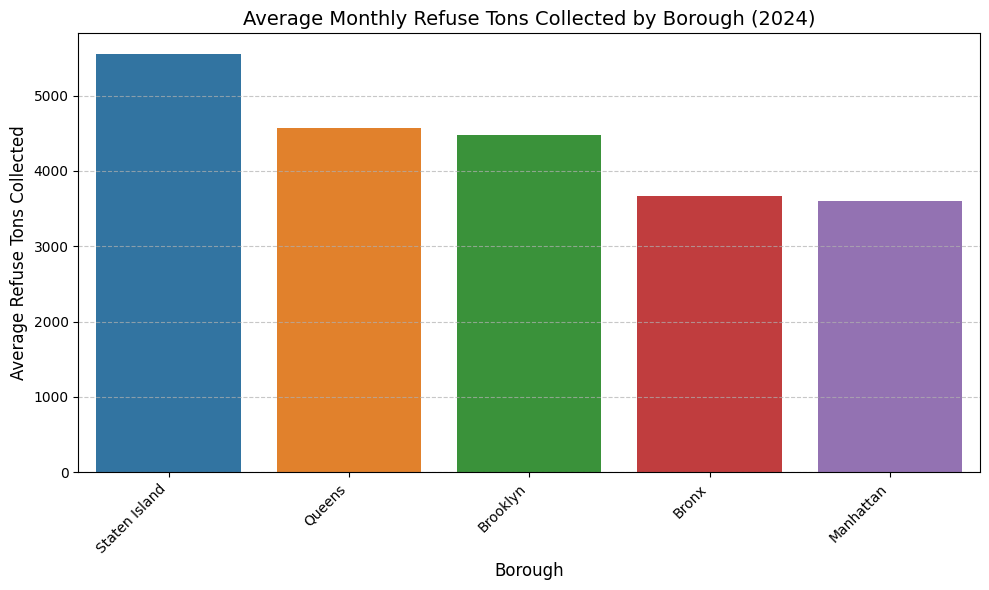

In [8]:
# Calculate average monthly refuse tonnage for each borough
borough_avg_refuse_tons = df_2024.groupby('BOROUGH')['REFUSETONSCOLLECTED'].mean().round(2)
borough_avg_refuse_tons_df = borough_avg_refuse_tons.reset_index()

# Sort from most to least
borough_avg_refuse_tons_df = borough_avg_refuse_tons_df.sort_values(by='REFUSETONSCOLLECTED', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='BOROUGH', y='REFUSETONSCOLLECTED', data=borough_avg_refuse_tons_df, hue='BOROUGH', legend=False)
plt.title('Average Monthly Refuse Tons Collected by Borough (2024)', fontsize=14)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Average Refuse Tons Collected', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Top 10 Community Districts by Refuse Tons Collected (2024)

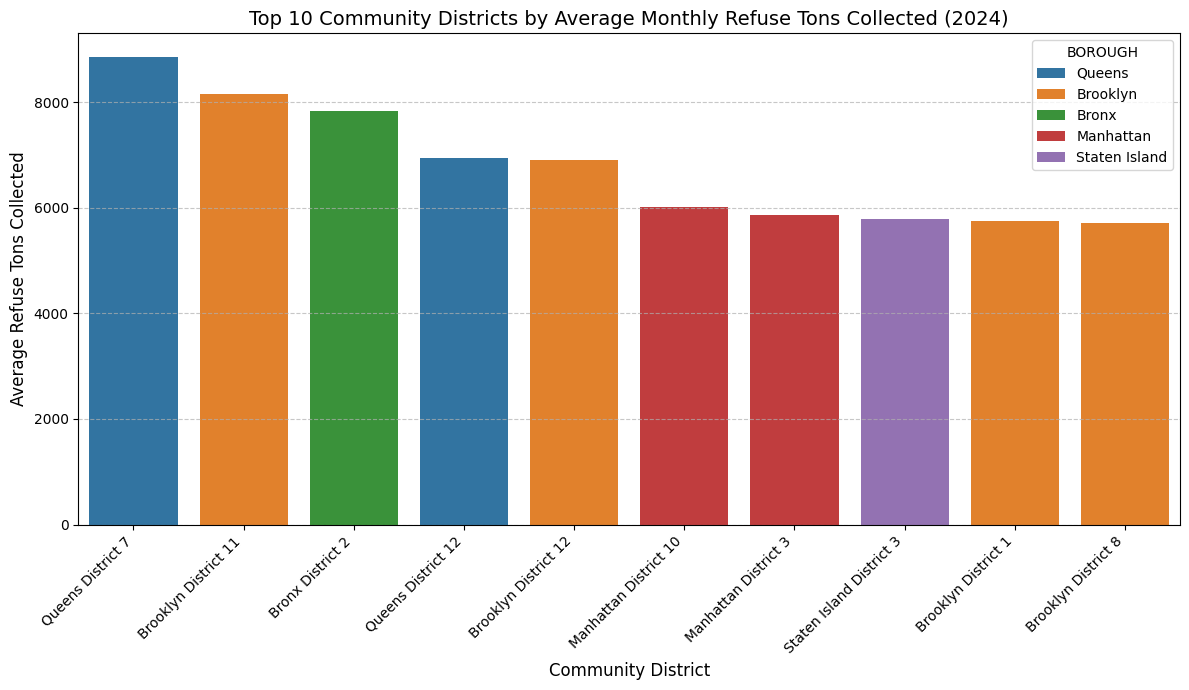

In [9]:
# The 'refuse_tonnage_2024_by_district' variable already contains the average monthly REFUSETONSCOLLECTED per district.
top_10_districts_by_refuse = refuse_tonnage_2024_by_district.reset_index().sort_values(by='REFUSETONSCOLLECTED', ascending=False).head(10)

# Create a 'District' column for better labeling on the plot
top_10_districts_by_refuse['District'] = top_10_districts_by_refuse['BOROUGH'] + ' District ' + top_10_districts_by_refuse['COMMUNITYDISTRICT'].astype(str)

plt.figure(figsize=(12, 7))
sns.barplot(x='District', y='REFUSETONSCOLLECTED', data=top_10_districts_by_refuse, hue='BOROUGH', dodge=False)
plt.title('Top 10 Community Districts by Average Monthly Refuse Tons Collected (2024)', fontsize=14)
plt.xlabel('Community District', fontsize=12)
plt.ylabel('Average Refuse Tons Collected', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Heatmap of Average Monthly Refuse Tons Collected by Borough and Community District (2024)

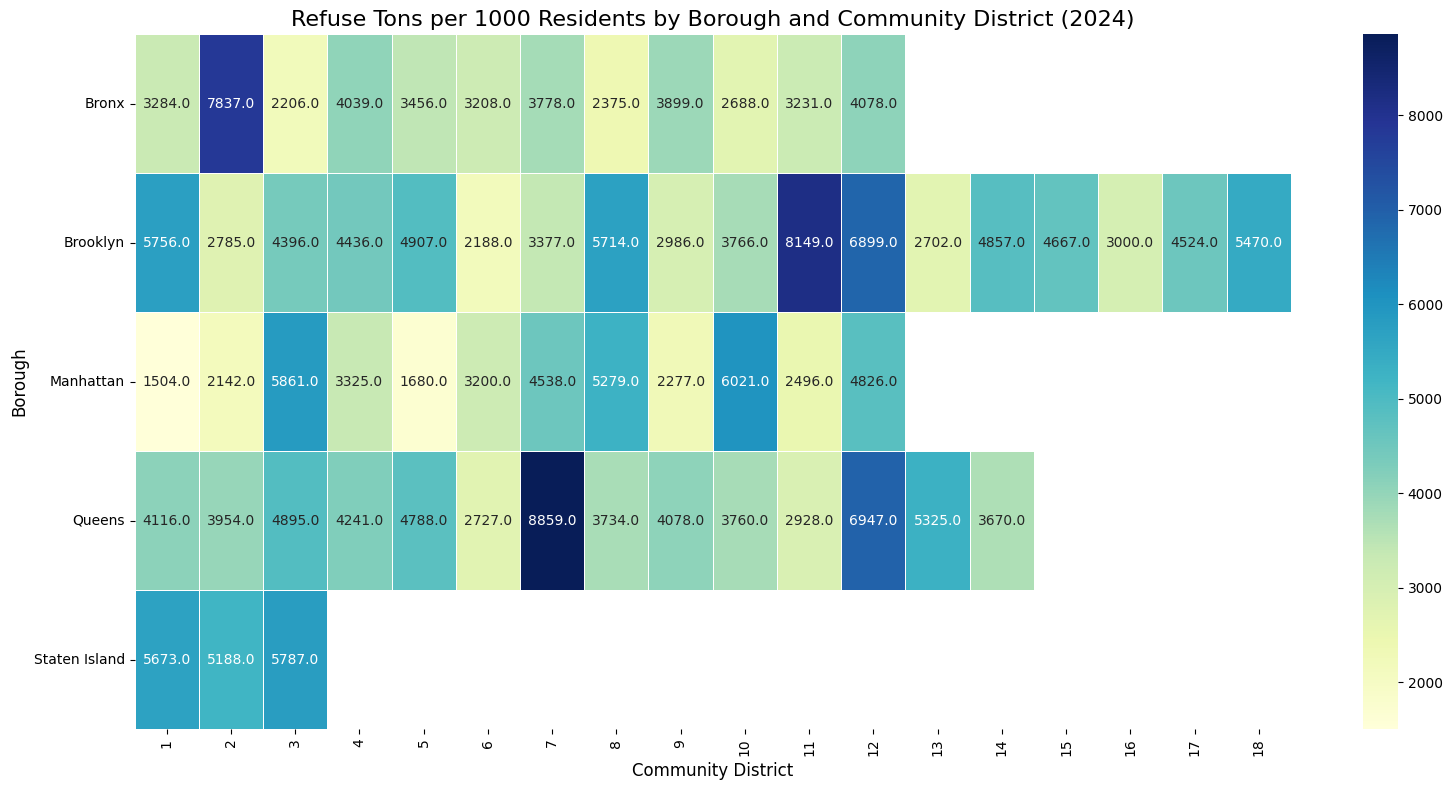

In [10]:
heatmap_data_refuse = refuse_tonnage_2024_by_district.unstack(level='COMMUNITYDISTRICT').fillna(0)

plt.figure(figsize=(16, 8))
mask = heatmap_data_refuse == 0
sns.heatmap(heatmap_data_refuse, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5, mask=mask)
plt.title('Refuse Tons per 1000 Residents by Borough and Community District (2024)', fontsize=16)
plt.xlabel('Community District', fontsize=12)
plt.ylabel('Borough', fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

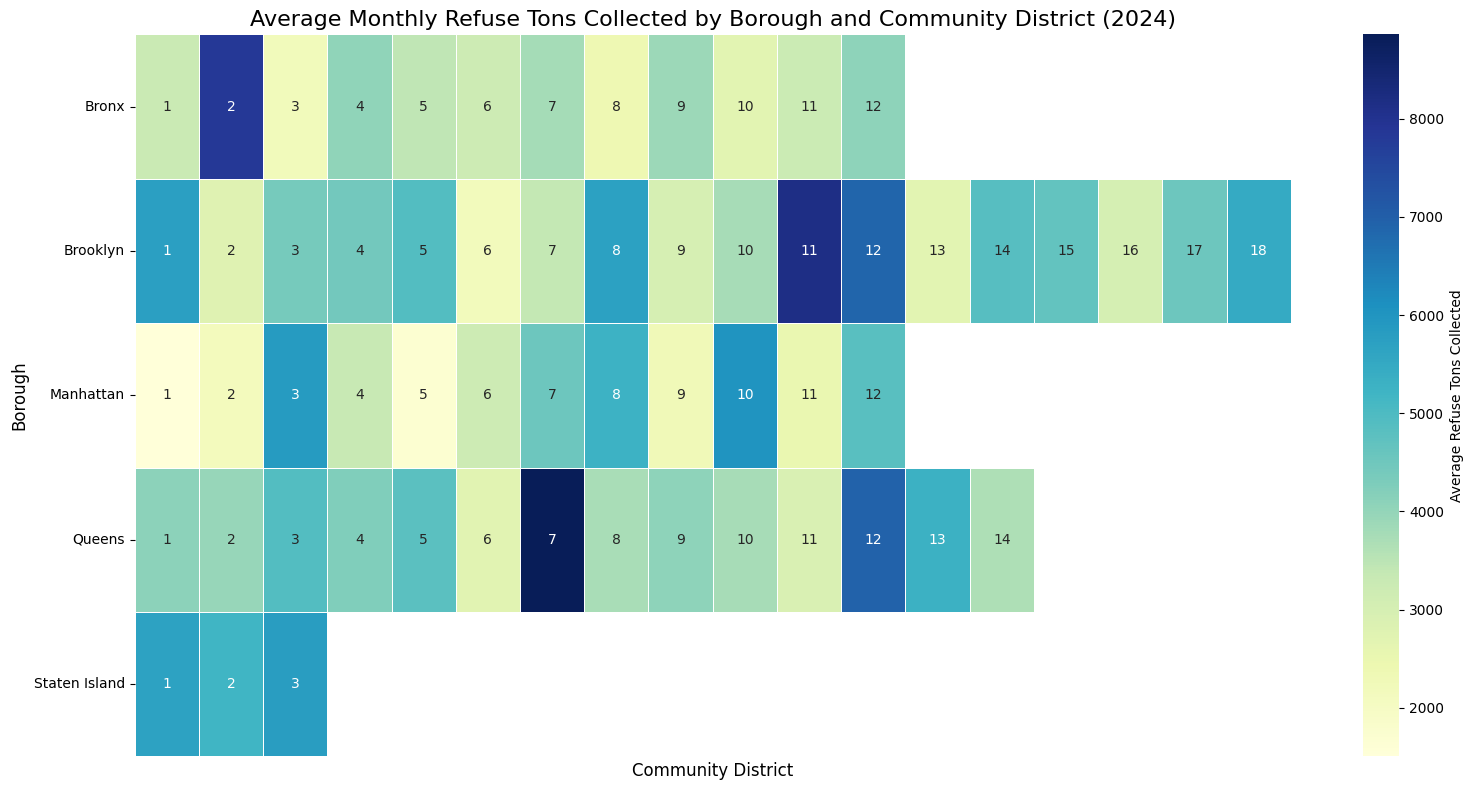

In [11]:
merged_df_for_annotations_refuse = refuse_tonnage_2024_by_district.reset_index().copy()
merged_df_for_annotations_refuse['CD_VALUE'] = merged_df_for_annotations_refuse['COMMUNITYDISTRICT']
cd_annotations_refuse = merged_df_for_annotations_refuse.pivot_table(index='BOROUGH', columns='COMMUNITYDISTRICT', values='CD_VALUE', aggfunc='first').fillna('')

plt.figure(figsize=(16, 8))
mask_refuse = heatmap_data_refuse == 0
sns.heatmap(heatmap_data_refuse, annot=cd_annotations_refuse, fmt=".0f", cmap="YlGnBu", linewidths=.5, mask=mask_refuse, cbar_kws={'label': 'Average Refuse Tons Collected'})
plt.title('Average Monthly Refuse Tons Collected by Borough and Community District (2024)', fontsize=16)
plt.xlabel('Community District', fontsize=12)
plt.ylabel('Borough', fontsize=12)
plt.xticks([]) # Hide x-axis ticks to show only CD numbers as annotations
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Part 2: Analysis based on Refuse Tons per 1000 Residents

In [13]:
merged_df['2010 Population'] = merged_df['2010 Population'].str.replace(',', '').astype(float)
merged_df['Refuse Tons per 1000 Residents'] = (merged_df['REFUSETONSCOLLECTED'] / merged_df['2010 Population']) * 1000
merged_df.head()

,BOROUGH,COMMUNITYDISTRICT,REFUSETONSCOLLECTED,2010 Population,District,Refuse Tons per 1000 Residents
0,Bronx,1,3284.0,91497.0,Bronx District 1,35.891887
1,Bronx,2,7837.0,52246.0,Bronx District 2,150.001914
2,Bronx,3,2206.0,79762.0,Bronx District 3,27.657280
3,Bronx,4,4039.0,146441.0,Bronx District 4,27.581074
4,Bronx,5,3456.0,128200.0,Bronx District 5,26.957878


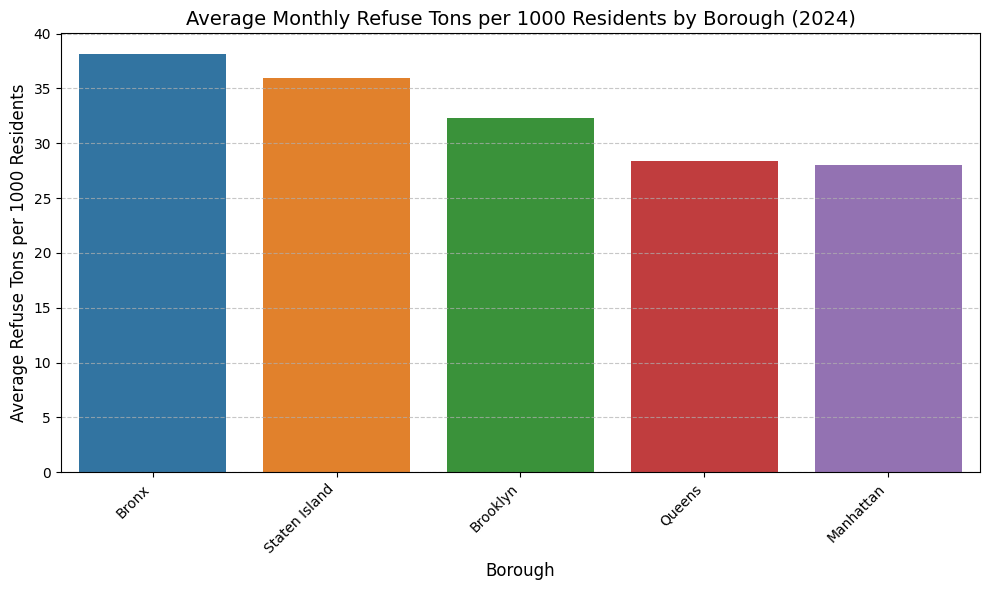

In [14]:
# Average monthly tonnage for each borough bar plot
borough_avg_refuse_per_resident = merged_df.groupby('BOROUGH')['Refuse Tons per 1000 Residents'].mean().round(2)
borough_avg_refuse_df = borough_avg_refuse_per_resident.reset_index()

# Sort from most to least
borough_avg_refuse_df = borough_avg_refuse_df.sort_values(by='Refuse Tons per 1000 Residents', ascending=False)

plt.figure(figsize=(10, 6))
# Color palette
sns.barplot(x='BOROUGH', y='Refuse Tons per 1000 Residents', data=borough_avg_refuse_df, hue='BOROUGH', legend=False)
plt.title('Average Monthly Refuse Tons per 1000 Residents by Borough (2024)', fontsize=14)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Average Refuse Tons per 1000 Residents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

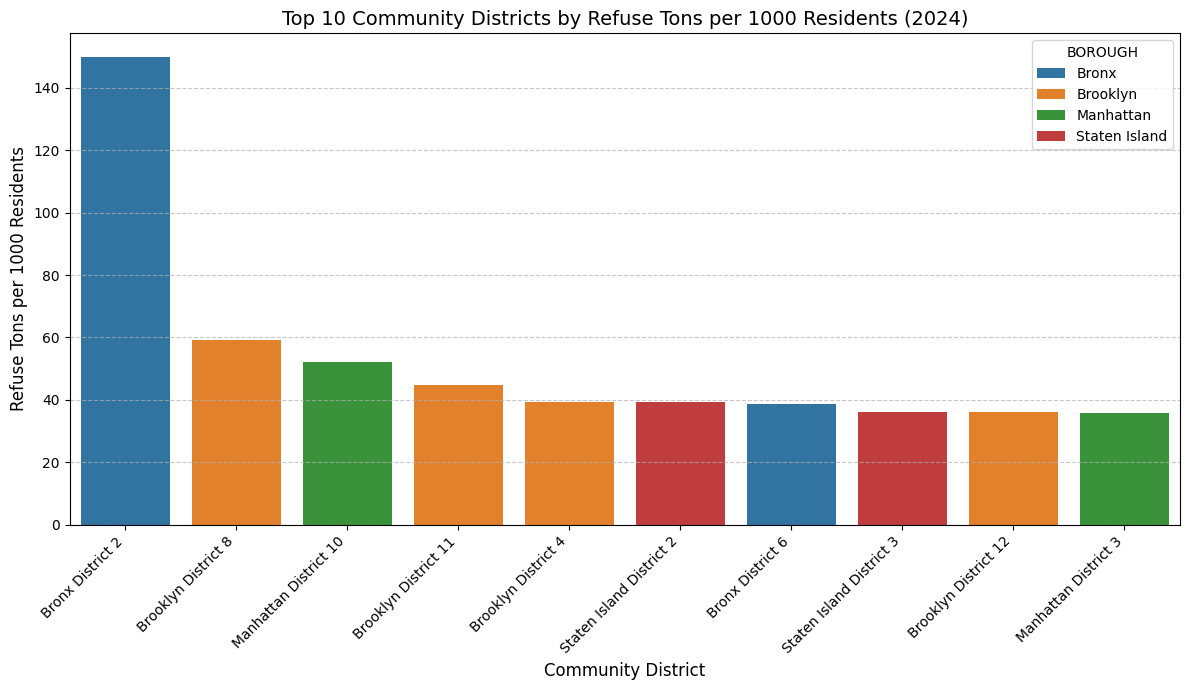

In [15]:
top_residents_refuse = merged_df.sort_values(by='Refuse Tons per 1000 Residents', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='District', y='Refuse Tons per 1000 Residents', data=top_residents_refuse, hue='BOROUGH', dodge=False)
plt.title('Top 10 Community Districts by Refuse Tons per 1000 Residents (2024)', fontsize=14)
plt.xlabel('Community District', fontsize=12)
plt.ylabel('Refuse Tons per 1000 Residents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Heat Map

In [16]:
heatmap_data = merged_df.pivot_table(index='BOROUGH', columns='COMMUNITYDISTRICT', values='Refuse Tons per 1000 Residents').fillna(0)
heatmap_data.head()

COMMUNITYDISTRICT,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
BOROUGH,,,,,,,,,,,,,,,,,,
Bronx,35.891887,150.001914,27.657280,27.581074,26.957878,38.526205,27.124047,23.345883,22.629398,22.327065,28.534337,26.768366,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Brooklyn,33.255721,27.957076,28.734843,39.384200,26.829455,20.896007,26.752753,59.324937,30.336588,30.251183,44.779400,36.048322,25.911506,30.230792,29.232697,34.694916,29.139721,28.262453
Manhattan,24.664633,23.795770,35.896054,32.204949,32.512144,22.417598,21.704195,24.004183,20.663745,52.029415,20.711802,25.397327,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Queens,21.537898,34.929329,28.529631,24.571548,28.299545,24.077982,35.815067,24.710966,28.454405,30.719958,25.147942,30.749959,28.235406,31.919150,0.000000,0.000000,0.000000,0.000000
Staten Island,32.277703,39.302137,36.121566,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


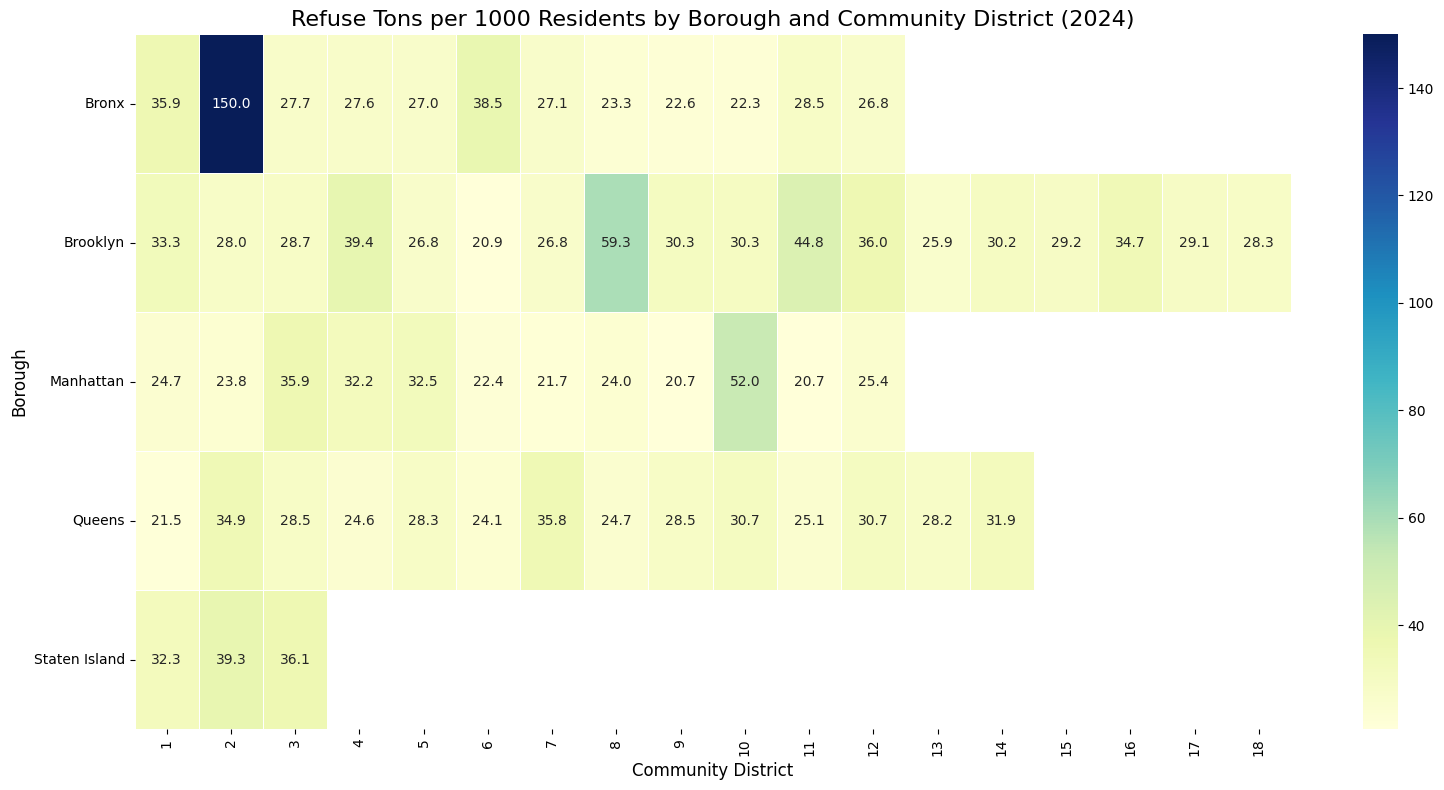

In [17]:
plt.figure(figsize=(16, 8))
mask = heatmap_data == 0
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5, mask=mask)
plt.title('Refuse Tons per 1000 Residents by Borough and Community District (2024)', fontsize=16)
plt.xlabel('Community District', fontsize=12)
plt.ylabel('Borough', fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

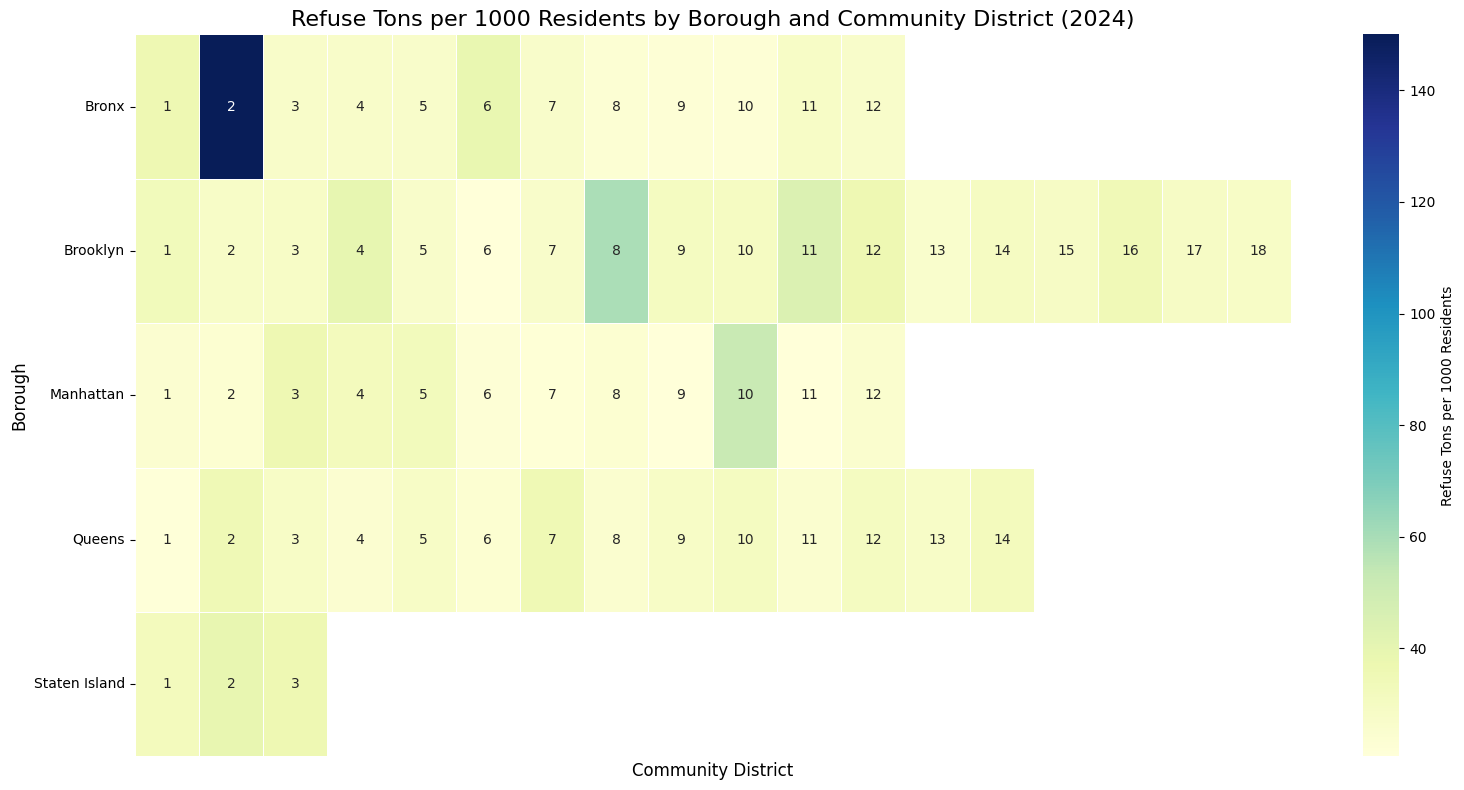

In [18]:
merged_df_for_annotations = merged_df.copy()
merged_df_for_annotations['CD_VALUE'] = merged_df_for_annotations['COMMUNITYDISTRICT']
cd_annotations = merged_df_for_annotations.pivot_table(index='BOROUGH', columns='COMMUNITYDISTRICT', values='CD_VALUE', aggfunc='first').fillna('')

plt.figure(figsize=(16, 8))
mask = heatmap_data == 0
sns.heatmap(heatmap_data, annot=cd_annotations, fmt=".0f", cmap="YlGnBu", linewidths=.5, mask=mask, cbar_kws={'label': 'Refuse Tons per 1000 Residents'})
plt.title('Refuse Tons per 1000 Residents by Borough and Community District (2024)', fontsize=16)
plt.xlabel('Community District', fontsize=12)
plt.ylabel('Borough', fontsize=12)
plt.xticks([])
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [66]:
top_10_districts_list = top_10_districts_by_refuse[['BOROUGH', 'COMMUNITYDISTRICT']].apply(tuple, axis=1).tolist()

df_filtered_top_10 = df[df[['BOROUGH', 'COMMUNITYDISTRICT']].apply(tuple, axis=1).isin(top_10_districts_list)].copy()

df_filtered_top_10_years = df_filtered_top_10[
    (df_filtered_top_10['MONTH'].dt.year >= 2014) &
    (df_filtered_top_10['MONTH'].dt.year <= 2024)
].copy()

df_filtered_top_10_years['YEAR'] = df_filtered_top_10_years['MONTH'].dt.year

In [67]:
yearly_avg_refuse_top_10 = df_filtered_top_10_years.groupby(['YEAR', 'BOROUGH', 'COMMUNITYDISTRICT'])['REFUSETONSCOLLECTED'].mean().reset_index()
yearly_avg_refuse_top_10['District'] = yearly_avg_refuse_top_10['BOROUGH'] + ' District ' + yearly_avg_refuse_top_10['COMMUNITYDISTRICT'].astype(str)

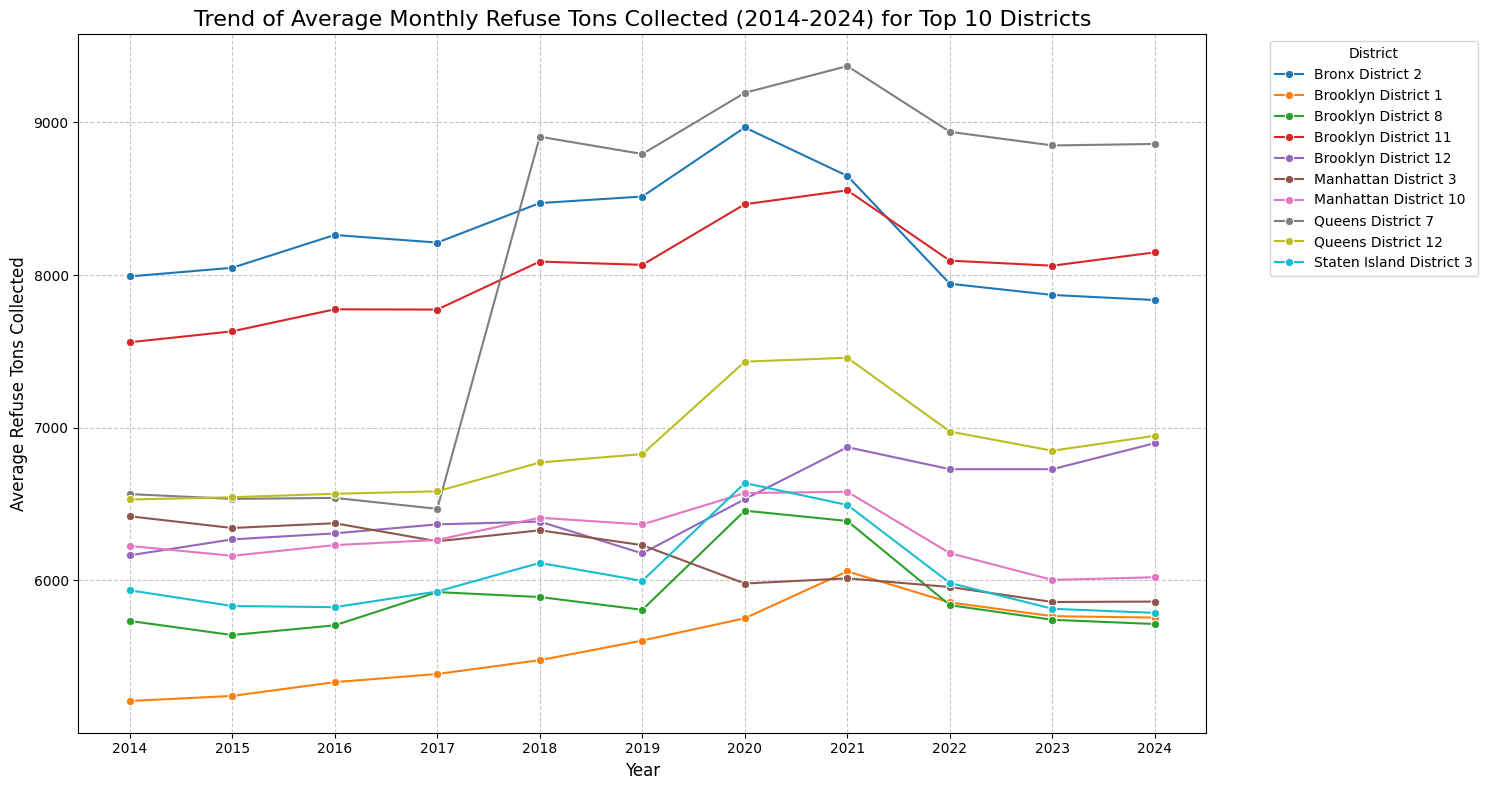

In [68]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=yearly_avg_refuse_top_10, x='YEAR', y='REFUSETONSCOLLECTED', hue='District', marker='o')
plt.title('Trend of Average Monthly Refuse Tons Collected (2014-2024) for Top 10 Districts', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Refuse Tons Collected', fontsize=12)
plt.xticks(yearly_avg_refuse_top_10['YEAR'].unique())
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='District')
plt.tight_layout()
plt.show()

Part 3: Trend of the highest tonnage community districts in the last 10 years.

In [19]:
# Filter df for bronx, district 2 from 2014 january to 2024 december
# Group by on this df by averaging the month per year

bronx_district2_df = df[(df['BOROUGH'] == 'Bronx') & (df['COMMUNITYDISTRICT'] == 2)].copy()
bronx_district2_df_filtered_years = bronx_district2_df[(bronx_district2_df['MONTH'].dt.year >= 2014) & (bronx_district2_df['MONTH'].dt.year <= 2024)].copy()
bronx_district2_df_filtered_years['YEAR'] = bronx_district2_df_filtered_years['MONTH'].dt.year
bronx_district2_refuse_yearly = bronx_district2_df_filtered_years.groupby('YEAR')['REFUSETONSCOLLECTED'].mean().reset_index()

bronx_district2_refuse_yearly.head()

,YEAR,REFUSETONSCOLLECTED
0,2014,7991.400000
1,2015,8047.975000
2,2016,8262.991667
3,2017,8213.100000
4,2018,8471.866667


In [20]:
# Filter pop_df for bronx, district 2

bronx_district2_pop = pop_df[(pop_df['BOROUGH'] == 'Bronx') & (pop_df['COMMUNITYDISTRICT'] == 2)]
print("Population data for Bronx, District 2:")
print(bronx_district2_pop.head())

Population data for Bronx, District 2:
  BOROUGH  COMMUNITYDISTRICT 2010 Population
1   Bronx                  2          52,246


In [21]:
# Merge them
# Calculate the Refuse Tons per 1000 Residents

bronx_district2_pop_value = float(bronx_district2_pop['2010 Population'].str.replace(',', '').iloc[0])
bronx_district2_refuse_yearly['2010 Population'] = bronx_district2_pop_value
bronx_district2_refuse_yearly['Refuse Tons per 1000 Residents'] = (bronx_district2_refuse_yearly['REFUSETONSCOLLECTED'] / bronx_district2_refuse_yearly['2010 Population']) * 1000
print("Yearly 'Refuse Tons per 1000 Residents' for Bronx, District 2 (2014-2024):")
print(bronx_district2_refuse_yearly.head())

Yearly 'Refuse Tons per 1000 Residents' for Bronx, District 2 (2014-2024):
   YEAR  REFUSETONSCOLLECTED  2010 Population  Refuse Tons per 1000 Residents
0  2014          7991.400000          52246.0                      152.957164
1  2015          8047.975000          52246.0                      154.040022
2  2016          8262.991667          52246.0                      158.155489
3  2017          8213.100000          52246.0                      157.200551
4  2018          8471.866667          52246.0                      162.153402


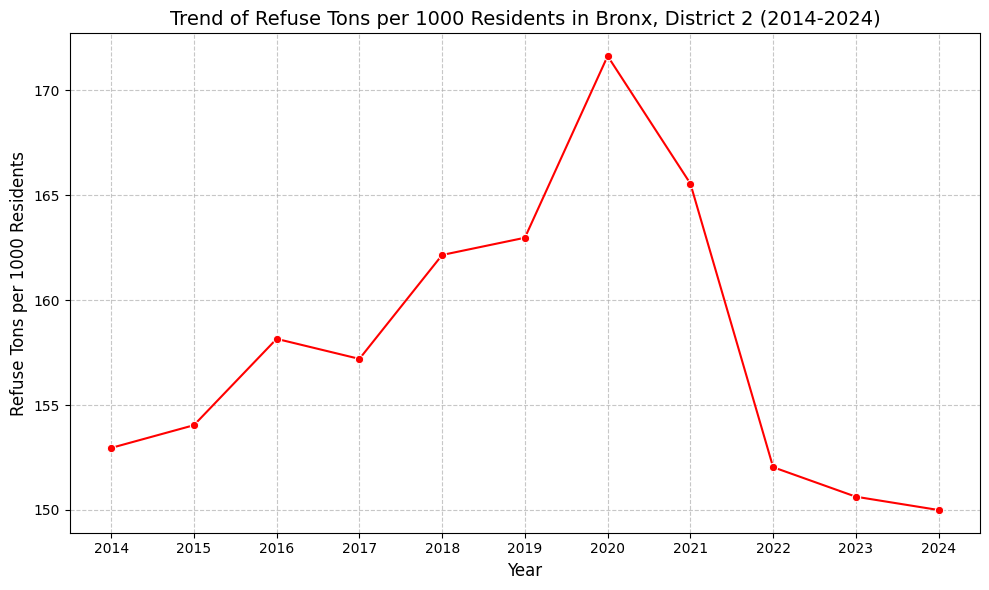

In [22]:
# Line graph of the last 10 years, Refuse Tons per 1000 for each year

plt.figure(figsize=(10, 6))
sns.lineplot(x='YEAR', y='Refuse Tons per 1000 Residents', data=bronx_district2_refuse_yearly, marker='o', color='red')
plt.title('Trend of Refuse Tons per 1000 Residents in Bronx, District 2 (2014-2024)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Refuse Tons per 1000 Residents', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(bronx_district2_refuse_yearly['YEAR'].unique())
plt.tight_layout()
plt.show()

## Part 3: Analysis based on 311 trash reports

Importing

In [23]:
df_311 = pd.read_csv('aggregated_complaint_community_district.csv')
df_311.info()
df_311.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29612 entries, 0 to 29611
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   year_month       29612 non-null  object
 1   Complaint Type   29612 non-null  object
 2   BoroCd           29612 non-null  int64 
 3   complaint_count  29612 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 925.5+ KB


,year_month,Complaint Type,BoroCd,complaint_count
0,2010-01,Basket,101,1
1,2010-01,Basket,102,5
2,2010-01,Basket,103,4
3,2010-01,Basket,104,7
4,2010-01,Basket,105,5


Data processing

In [28]:
# Filter for Complaint Type "Collection" and 2024
df_311['year_month'] = pd.to_datetime(df_311['year_month'])
df_311_2024_collection = df_311[(df_311['year_month'].dt.year == 2024) & (df_311['Complaint Type'] == 'Collection')]

# Group by month, sum the complaint count
df_311_2024_collection_copy = df_311_2024_collection.copy()
df_311_2024_collection_copy['month'] = df_311_2024_collection_copy['year_month'].dt.month
monthly_complaints = df_311_2024_collection_copy.groupby('month')['complaint_count'].sum().reset_index()

In [29]:
monthly_complaints.head()

,month,complaint_count
0,1,2436
1,2,1749
2,3,2972
3,4,2655
4,5,2735


In [31]:
top_10_districts_by_refuse

,BOROUGH,COMMUNITYDISTRICT,REFUSETONSCOLLECTED,District
48,Queens,7,8859.0,Queens District 7
22,Brooklyn,11,8149.0,Brooklyn District 11
1,Bronx,2,7837.0,Bronx District 2
53,Queens,12,6947.0,Queens District 12
23,Brooklyn,12,6899.0,Brooklyn District 12
39,Manhattan,10,6021.0,Manhattan District 10
32,Manhattan,3,5861.0,Manhattan District 3
58,Staten Island,3,5787.0,Staten Island District 3
12,Brooklyn,1,5756.0,Brooklyn District 1
19,Brooklyn,8,5714.0,Brooklyn District 8


In [45]:
borough_code_map = {
    'Manhattan': 1,
    'Bronx': 2,
    'Brooklyn': 3,
    'Queens': 4,
    'Staten Island': 5
}

# For all 2024
merged_df['BoroughCode'] = merged_df['BOROUGH'].map(borough_code_map)
merged_df['COMMUNITYDISTRICT_STR'] = merged_df['COMMUNITYDISTRICT'].astype(str).str.zfill(2)
merged_df['BoroCd'] = merged_df['BoroughCode'].astype(str) + merged_df['COMMUNITYDISTRICT_STR']

# For just the top 10 districts with high trash
top_10_districts_by_refuse['BoroughCode'] = top_10_districts_by_refuse['BOROUGH'].map(borough_code_map)
top_10_districts_by_refuse['COMMUNITYDISTRICT_STR'] = top_10_districts_by_refuse['COMMUNITYDISTRICT'].astype(str).str.zfill(2)
top_10_districts_by_refuse['BoroCd'] = top_10_districts_by_refuse['BoroughCode'].astype(str) + top_10_districts_by_refuse['COMMUNITYDISTRICT_STR']

top_10_districts_by_refuse.head()

,BOROUGH,COMMUNITYDISTRICT,REFUSETONSCOLLECTED,District,BoroughCode,COMMUNITYDISTRICT_STR,BoroCd
48,Queens,7,8859.0,Queens District 7,4,07,407
22,Brooklyn,11,8149.0,Brooklyn District 11,3,11,311
1,Bronx,2,7837.0,Bronx District 2,2,02,202
53,Queens,12,6947.0,Queens District 12,4,12,412
23,Brooklyn,12,6899.0,Brooklyn District 12,3,12,312


In [46]:
# For all 2024
merged_df.head()

,BOROUGH,COMMUNITYDISTRICT,REFUSETONSCOLLECTED,2010 Population,District,Refuse Tons per 1000 Residents,BoroughCode,COMMUNITYDISTRICT_STR,BoroCd
0,Bronx,1,3284.0,91497.0,Bronx District 1,35.891887,2,01,201
1,Bronx,2,7837.0,52246.0,Bronx District 2,150.001914,2,02,202
2,Bronx,3,2206.0,79762.0,Bronx District 3,27.657280,2,03,203
3,Bronx,4,4039.0,146441.0,Bronx District 4,27.581074,2,04,204
4,Bronx,5,3456.0,128200.0,Bronx District 5,26.957878,2,05,205


In [94]:
# Df for mapping
complaints_by_district_2024 = df_311_2024_collection.groupby('BoroCd')['complaint_count'].sum().reset_index()
complaints_by_district_2024['BoroCd'] = complaints_by_district_2024['BoroCd'].astype(str)

merged_with_complaints = pd.merge(merged_df, complaints_by_district_2024, on='BoroCd', how='left')

tonnage_311_df = merged_with_complaints[['BOROUGH', 'District', 'REFUSETONSCOLLECTED', 'complaint_count']]
tonnage_311_df.head()

,BOROUGH,District,REFUSETONSCOLLECTED,complaint_count
0,Bronx,Bronx District 1,3284.0,184
1,Bronx,Bronx District 2,7837.0,107
2,Bronx,Bronx District 3,2206.0,141
3,Bronx,Bronx District 4,4039.0,178
4,Bronx,Bronx District 5,3456.0,132


In [99]:
# A df with just the top 10
complaints_by_district_2024 = df_311_2024_collection.groupby('BoroCd')['complaint_count'].sum().reset_index()
complaints_by_district_2024['BoroCd'] = complaints_by_district_2024['BoroCd'].astype(str)

merged_top_10_with_complaints = pd.merge(top_10_districts_by_refuse, complaints_by_district_2024, on='BoroCd', how='left')

tonnage_311_top_10_df = merged_top_10_with_complaints[['BOROUGH','District', 'REFUSETONSCOLLECTED', 'complaint_count']]

tonnage_311_top_10_df

,BOROUGH,District,REFUSETONSCOLLECTED,complaint_count
0,Queens,Queens District 7,8859.0,771
1,Brooklyn,Brooklyn District 11,8149.0,803
2,Bronx,Bronx District 2,7837.0,107
3,Queens,Queens District 12,6947.0,1445
4,Brooklyn,Brooklyn District 12,6899.0,1120
5,Manhattan,Manhattan District 10,6021.0,470
6,Manhattan,Manhattan District 3,5861.0,343
7,Staten Island,Staten Island District 3,5787.0,1421
8,Brooklyn,Brooklyn District 1,5756.0,1408
9,Brooklyn,Brooklyn District 8,5714.0,494


Analyses

In [78]:
# Making mapping data
tonnage_311_df = tonnage_311_df.copy()
tonnage_311_df['Refuse_Complaint_Ratio'] = (tonnage_311_df['complaint_count'] / tonnage_311_top_10_df['REFUSETONSCOLLECTED']) * 100
tonnage_311_df.head()

,District,REFUSETONSCOLLECTED,complaint_count,Refuse_Complaint_Ratio
0,Bronx District 1,3284.0,184,2.076984
1,Bronx District 2,7837.0,107,1.313045
2,Bronx District 3,2206.0,141,1.799158
3,Bronx District 4,4039.0,178,2.562257
4,Bronx District 5,3456.0,132,1.913321


Districts with high tonnage:
*   Low 311 reports: sanitation effectively manages high waste
*   High 311 reports: high waste, poor sanitation
    *   Need attention

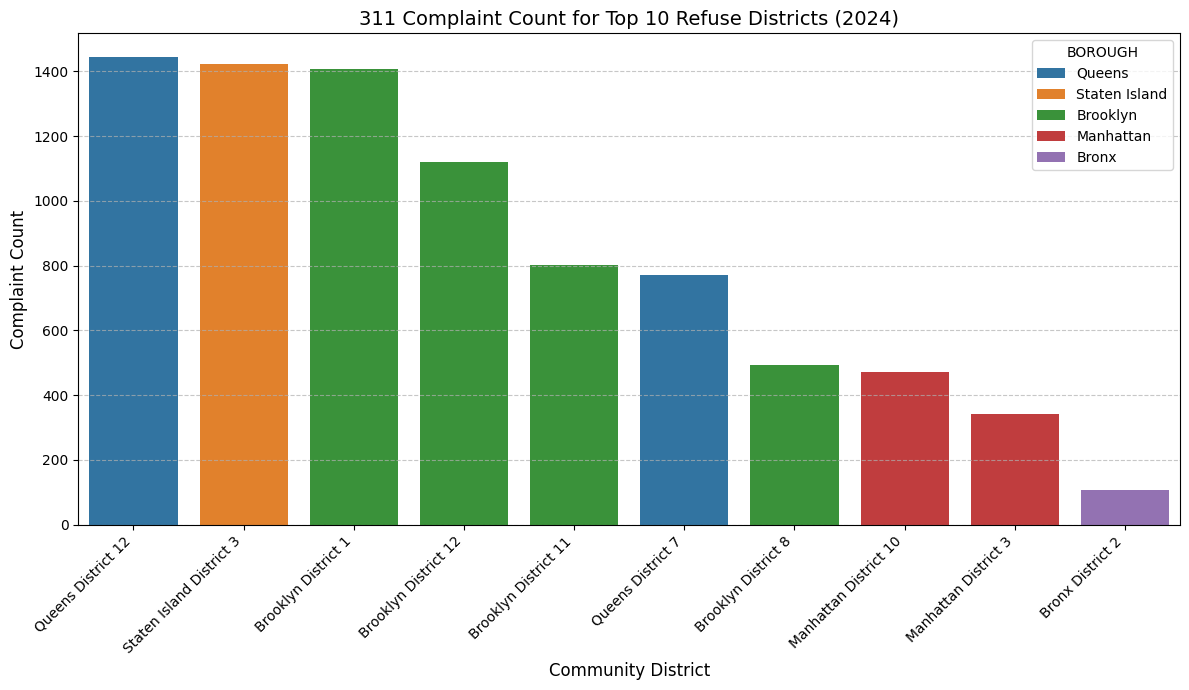

In [100]:
# Sort the DataFrame by 'complaint_count' from most to least
tonnage_311_top_10_df_sorted = tonnage_311_top_10_df.sort_values(by='complaint_count', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='District', y='complaint_count', data=tonnage_311_top_10_df_sorted, hue='BOROUGH', dodge=False)
plt.title('311 Complaint Count for Top 10 Refuse Districts (2024)', fontsize=14)
plt.xlabel('Community District', fontsize=12)
plt.ylabel('Complaint Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

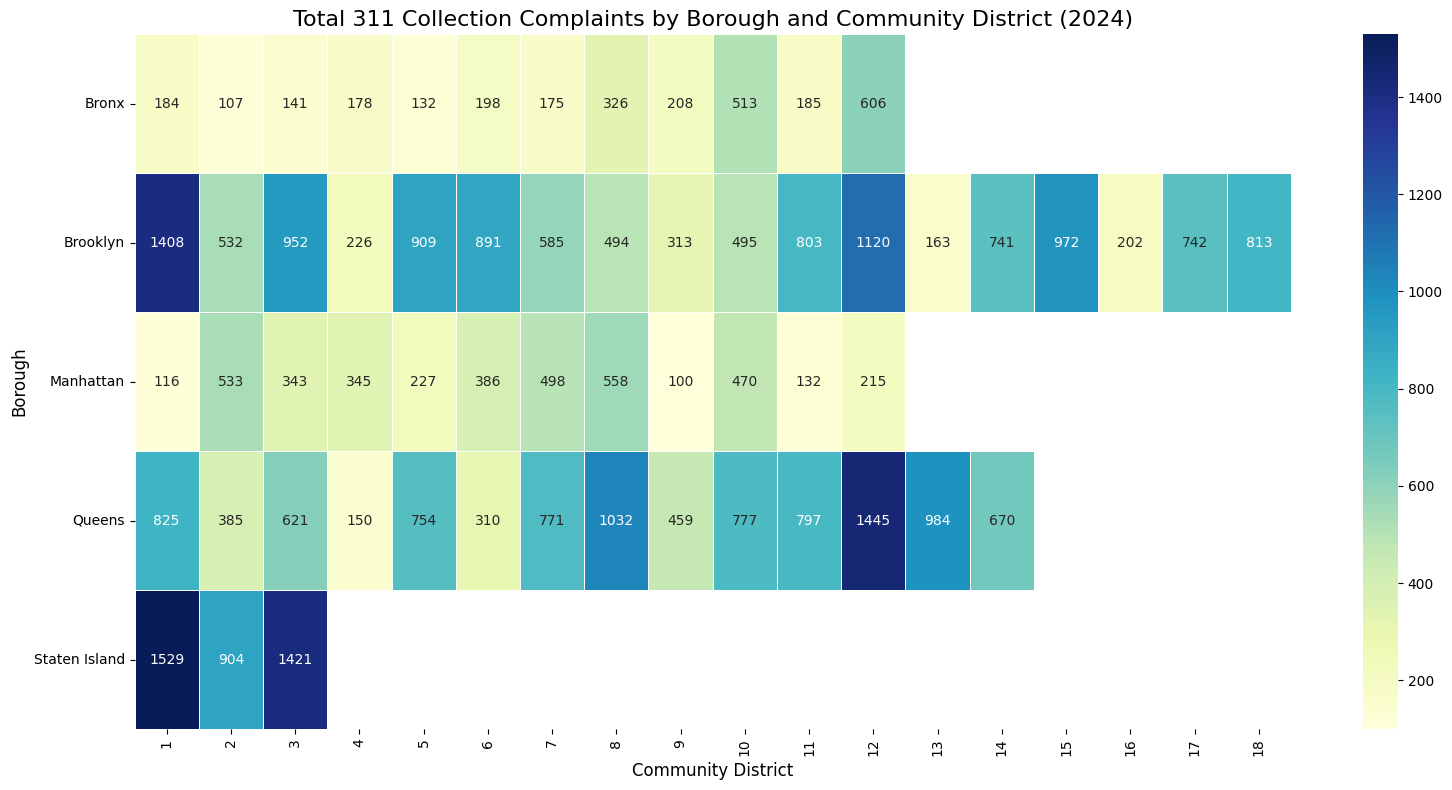

In [81]:
heatmap_data_311_complaints = merged_with_complaints.pivot_table(
    index='BOROUGH',
    columns='COMMUNITYDISTRICT',
    values='complaint_count'
).fillna(0)

plt.figure(figsize=(16, 8))
mask_311 = heatmap_data_311_complaints == 0
sns.heatmap(heatmap_data_311_complaints, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5, mask=mask_311)
plt.title('Total 311 Collection Complaints by Borough and Community District (2024)', fontsize=16)
plt.xlabel('Community District', fontsize=12)
plt.ylabel('Borough', fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

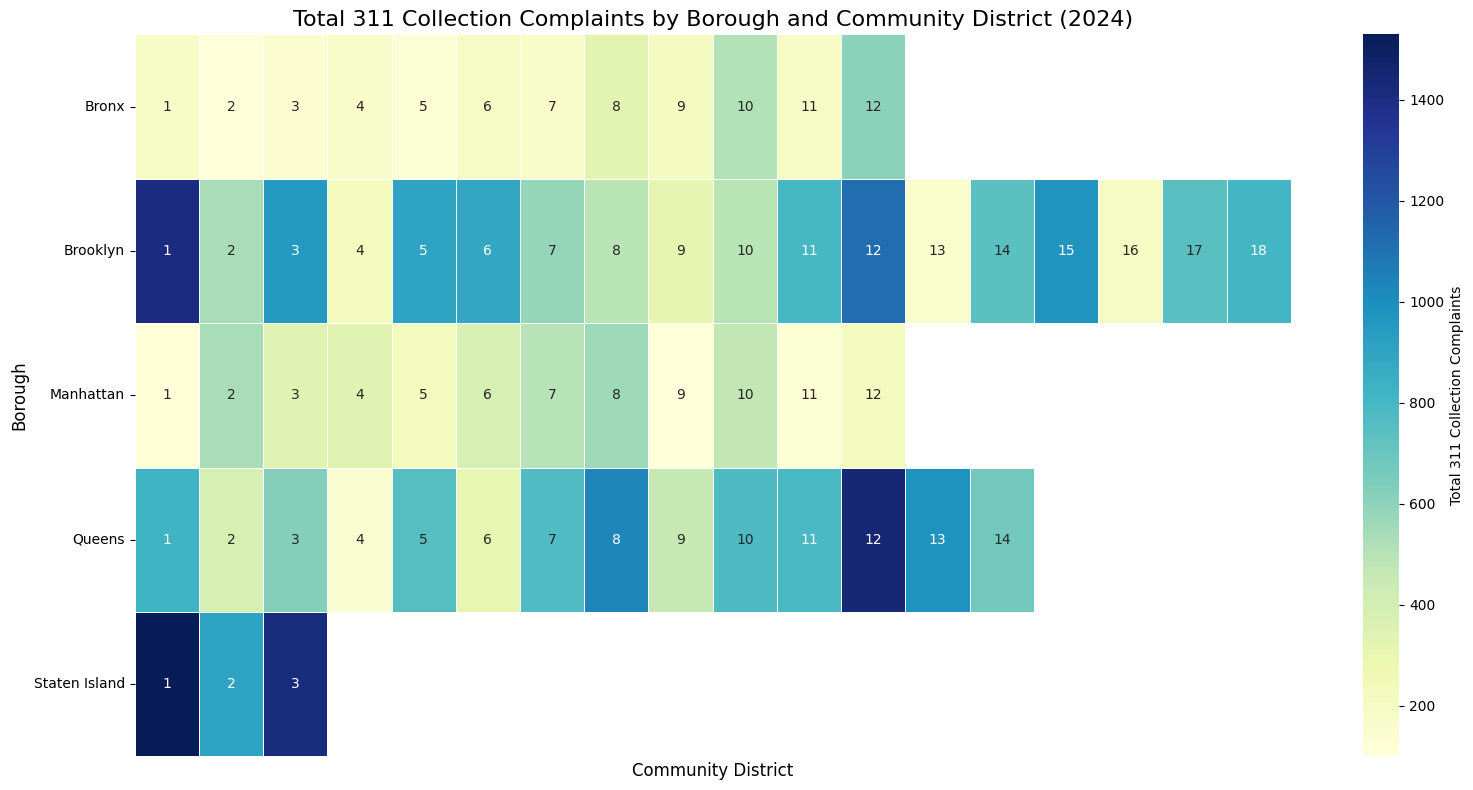

In [82]:
merged_df_for_annotations_311 = merged_with_complaints.copy()
merged_df_for_annotations_311['CD_VALUE'] = merged_df_for_annotations_311['COMMUNITYDISTRICT']
cd_annotations_311 = merged_df_for_annotations_311.pivot_table(index='BOROUGH', columns='COMMUNITYDISTRICT', values='CD_VALUE', aggfunc='first').fillna('')

plt.figure(figsize=(16, 8))
mask_311 = heatmap_data_311_complaints == 0
sns.heatmap(heatmap_data_311_complaints, annot=cd_annotations_311, fmt=".0f", cmap="YlGnBu", linewidths=.5, mask=mask_311, cbar_kws={'label': 'Total 311 Collection Complaints'})
plt.title('Total 311 Collection Complaints by Borough and Community District (2024)', fontsize=16)
plt.xlabel('Community District', fontsize=12)
plt.ylabel('Borough', fontsize=12)
plt.xticks([]) # Hide x-axis ticks to show only CD numbers as annotations
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [97]:
top_10_complaint_districts = complaints_by_district_2024.sort_values(by='complaint_count', ascending=False).head(10)

top_10_districts_by_complaints = pd.merge(
    top_10_complaint_districts,
    merged_with_complaints[['BoroCd', 'District', 'BOROUGH']], # Include BOROUGH here
    on='BoroCd',
    how='left'
)
top_10_districts_by_complaints_clean = pd.merge(
    top_10_districts_by_complaints,
    merged_with_complaints[['BoroCd', 'REFUSETONSCOLLECTED']],
    on='BoroCd',
    how='left'
)

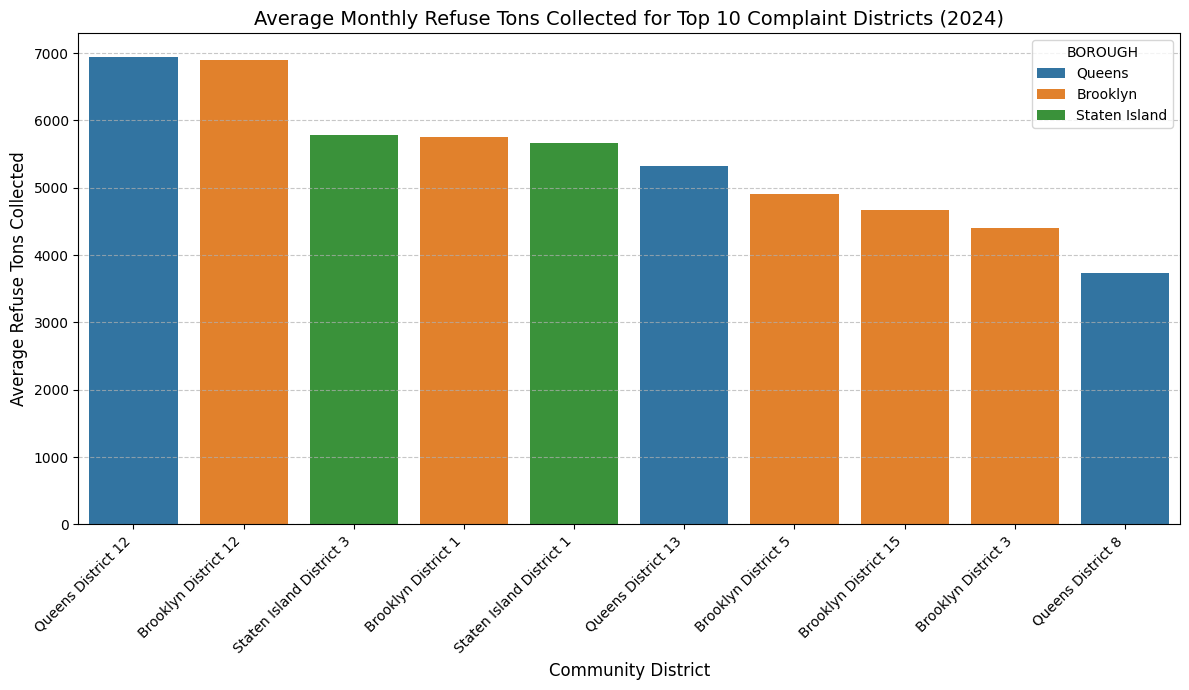

In [98]:
plt.figure(figsize=(12, 7))
sns.barplot(x='District', y='REFUSETONSCOLLECTED', data=top_10_districts_by_complaints_clean.sort_values(by='REFUSETONSCOLLECTED', ascending=False), hue='BOROUGH', dodge=False)
plt.title('Average Monthly Refuse Tons Collected for Top 10 Complaint Districts (2024)', fontsize=14)
plt.xlabel('Community District', fontsize=12)
plt.ylabel('Average Refuse Tons Collected', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()